In [76]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict


In [77]:
class BatsManState(TypedDict):
    runs:int
    balls_played:int
    fours:int
    sixes:int

    sr:float
    bpb:float
    bp:float
    summary:str

In [78]:
def calculate_sr(state:BatsManState)->BatsManState:
    balls=state['balls_played']
    runs=state['runs']
    if balls==0:
        sr=0.0
    else:
        sr=(runs/balls)*100

    return {'sr': sr}

In [79]:
def calculate_bpb(state:BatsManState)->BatsManState:
    balls=state['balls_played']
    boundarys=state['fours']+state['sixes']
    if balls==0:
        bpb=0.0
    else:
        bpb=(balls/boundarys)*100

    return {'bpb': bpb}

In [80]:
def calculate_bp(state:BatsManState)->BatsManState:
    runs=state['runs']
    boundarys=state['fours']*4+state['sixes']*6
    if runs==0:
        bp=0.0
    else:
        bp=(boundarys/runs)*100

    return {'bp': bp}

In [81]:
def generate_summary(state: BatsManState):

    summary = f"""
Strike Rate - {state['sr']} \n
Balls per boundary - {state['bpb']} \n
Boundary percent - {state['bp']}
"""
    
    return {'summary': summary}

In [82]:
graph=StateGraph(BatsManState)

In [83]:
graph.add_node("strike_rate",calculate_sr)
graph.add_node("boundary_per_balls",calculate_bpb)
graph.add_node("boundary_percentage",calculate_bp)
graph.add_node("summary",generate_summary)

In [84]:
graph.add_edge(START,'strike_rate')
graph.add_edge(START,'boundary_per_balls')
graph.add_edge(START,'boundary_percentage')

graph.add_edge('strike_rate','summary')
graph.add_edge('boundary_per_balls','summary')
graph.add_edge('boundary_percentage','summary')

graph.add_edge('summary',END)
workflow=graph.compile()

In [85]:
intial_state = {
    'runs': 93,
    'balls_played': 38,
    'fours': 7,
    'sixes': 10
}
workflow.invoke(intial_state)

{'runs': 93,
 'balls_played': 38,
 'fours': 7,
 'sixes': 10,
 'sr': 244.73684210526315,
 'bpb': 223.52941176470588,
 'bp': 94.6236559139785,
 'summary': '\nStrike Rate - 244.73684210526315 \n\nBalls per boundary - 223.52941176470588 \n\nBoundary percent - 94.6236559139785\n'}

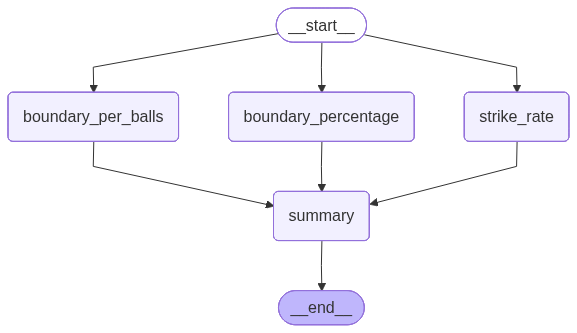

In [86]:
graph.compile()